# ENGR 1451/2451 — Weekly Assignment 3
**10 points**

This assignment applies programming, normal-approximation, and central-limit-theorem ideas.


**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.


## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.


## Setup

No external data file is needed for this assignment.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm


## LE3-1. Detecting abrupt changes in a sequence (2 pts)

Thickness is measured at consecutive positions along a coated sample. A change of **5 nm or more in magnitude** between neighboring positions is considered abrupt.

### A. Loop solution (1 pt)

Using `range`, an `if` statement, and `.append()`, calculate each change from one position to the next and store it in `changes_loop`. Store the position pairs with abrupt changes in `abrupt_pairs_loop`. **Report position numbers starting at 1**; for example, `(1, 2)` means the change from the first measurement to the second measurement.


In [2]:
thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]
settings = {"abrupt_change_nm": 5}

changes_loop = []
abrupt_pairs_loop = []

# Your code here
length = len(thickness_nm) -1
for i in range(length):
    change = thickness_nm[i+1] - thickness_nm[i]
    changes_loop.append(change)
    if change >= 5 or change <= -5:
        abrupt_pairs_loop.append([i+1,i + 2]) # additional 1 added to account for 0 indexing

print(changes_loop)
print(abrupt_pairs_loop)

[2, -1, 6, 1, -3, 6, -1]
[[3, 4], [6, 7]]


### B. Vectorized solution (1 pt)

Convert the data to a NumPy array and use `np.diff()` to calculate the same changes without an explicit loop. Use a Boolean mask to identify abrupt changes. Verify agreement with the loop solution and report the affected position pairs.

**Answer:**


In [3]:
# Your vectorized code and comparison here
vector_thickness_nm = np.array(thickness_nm)
vector_changes = np.diff(vector_thickness_nm)
print(vector_changes)

mask = np.abs(vector_changes) >= 5 #absolute value to account for +5 or -5 changes
print(mask)
idx = np.where(mask)[0]
print(idx)
pairs = np.vstack((idx + 1, idx + 2))
print(pairs)

[ 2 -1  6  1 -3  6 -1]
[False False  True False False  True False]
[2 5]
[[3 6]
 [4 7]]


## LE3-2. Raw scores and a normal approximation (2 pts)

For Part B, use a normal model with **mean = 50** and **SD = 10**. **Do not estimate these values from the raw scores.**

### A. Density histogram from raw data (1 pt)

Make a **density histogram** using the supplied equal-width bins. Then use `np.histogram(..., density=True)` to calculate the density heights and verify

\[
\sum_i (\text{density}_i)(\text{bin width}_i)=1.
\]

Also calculate the sum of the density heights. Why do the heights themselves not need to sum to 1?


1.0
0.2


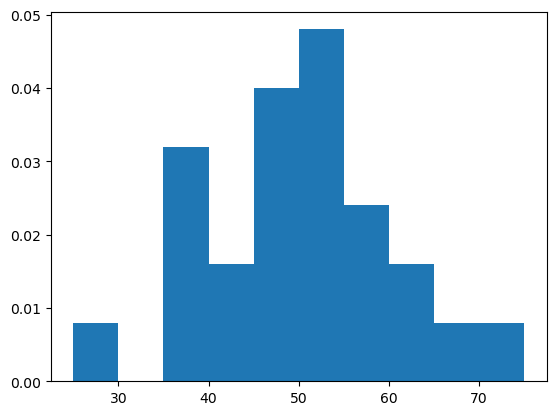

In [13]:
scores = np.array([
    39, 41, 47, 58, 65, 37, 37, 49, 56, 59, 62, 36, 48,
    52, 64, 29, 44, 47, 49, 52, 53, 54, 72, 50, 50
])

bins = np.arange(25, 76, 5)

# Create the density histogram and verify its total area.
# Your code here
plt.hist(scores, bins, density = True)
plt.show


#verify with numpy
counts, edges = np.histogram(scores, bins, density = True)
bin_width = edges[1] - edges[0]
#relative_frequency = counts / scores.size

histogram_area = (counts * bin_width).sum()
print(histogram_area)
densities_sum = counts.sum()
print(densities_sum)

**Answer:**
A density histogram normalizes the area. Therefore, the sum of the density bar heights is only one part of the calculation since it needs to be multiplied by the bin widths.

### B. Approximation versus actual data (1 pt)

Using the supplied normal model with **mean = 50** and **SD = 10**, estimate the percentage and number of the 25 scores within **1.25 SDs** of the mean. Then count how many raw scores actually fall in that interval. Round the fitted count to the nearest whole student and compare.


In [26]:
# Your normal approximation and observed count here
mean = 50
sd = 10
norm_model = norm(loc = mean, scale = sd)
cutoff = sd*1.25
norm_compare = norm_model.cdf(mean + cutoff) - norm_model.cdf(mean - cutoff)
print("percent of students that fall between 1.25 SD's of the mean is", norm_compare*100)
students_in_interval = np.count_nonzero((scores < (mean + cutoff)) & (scores > (mean - cutoff)))
print(students_in_interval, " students fall in interval")
fitted_students_in_interval = (norm_model.cdf(cutoff+mean) - norm_model.cdf(cutoff-mean))*25
print(round(fitted_students_in_interval), "students fall in interval in normal model")

percent of students that fall between 1.25 SD's of the mean is 78.87004526662894
18  students fall in interval
22 students fall in interval in normal model


**Answer:**
more students fell in interval in the fitted normal model for scores

## LE3-3. Normal model for engineering specifications (4 pts)

Shaft diameters are modeled by a normal curve with \(\mu=10.00\) mm and \(\sigma=0.12\) mm. The acceptable range is **9.80–10.20 mm**. Assume the normal model is appropriate.

### A. Fraction meeting specification (1.5 pts)

Calculate the fitted percentages **below**, **within**, and **above** specification, and check that they total about 100%. Why are the two tail percentages equal?


In [14]:
def create_norm_with_percents(mean,std,upper,lower):
    norm_shaft = norm(loc = mean, scale = std)
    percent_below = norm_shaft.cdf(lower)
    percent_above = 1 - norm_shaft.cdf(upper)
    percent_within = norm_shaft.cdf(upper) - norm_shaft.cdf(lower)
    return (norm_shaft, percent_below, percent_above, percent_within)

mean_diameter = 10.00
std_diameter = 0.12
lower_spec = 9.80
upper_spec = 10.20

# Create the normal model and calculate the probabilities here
norm_shaft, percent_below, percent_above, percent_within = create_norm_with_percents(mean_diameter, std_diameter, upper_spec, lower_spec)

print(percent_below, " + ", percent_above, " + ", percent_within, " = ", percent_below+percent_above+percent_within)

0.0477903522728153  +  0.04779035227281525  +  0.9044192954543695  =  1.0


**Answer:**


### B. Upper 99th-percentile threshold (1 pt)

Find an upper threshold that only **1%** of shafts are expected to exceed. Use `ppf` or `isf`, then verify the result with a right-tail probability.


In [14]:
# Your cutoff and verification here
upper_cutoff = norm_shaft.ppf(0.99)
upper_cutoff

10.2791617448849

### C. Process drift (1.5 pts)

Suppose the process mean shifts to **10.05 mm**, while $\sigma=0.12$ mm and the specifications stay fixed. Recalculate the percentages below and above specification and the total percentage rejected. Compare with the original process. Which side now causes most rejections, and why?


In [15]:
shifted_mean = 10.05
#didn't read the question: so this doesn't apply
#mean_shift = shifted_mean - mean_diameter
#shifted_lower = lower_spec + mean_shift
#shifted_upper = upper_spec + mean_shift
# Your shifted-process calculations here

shift_norm_shaft, shift_p_bel, shift_p_upp, shift_p_wit = create_norm_with_percents(shifted_mean, std_diameter, upper_spec, lower_spec)
print("percent below: ", shift_p_bel)
print("percent above: ", shift_p_upp)
print("percent within: ", shift_p_wit)



percent below:  0.018610425189886332
percent above:  0.10564977366685746
percent within:  0.8757398011432562


**Answer:**
now upper causes more rejects because mean drifted upwards

## LE3-4. CLT with a skewed process (2 pts)

For this exercise, we will start with an **exponential distribution**. An exponential distribution is a continuous distribution often used to model **waiting times**. It only produces positive values and is **strongly right-skewed**: short waiting times are common, while very long waiting times are possible but less common.

In NumPy,

```python
rng.exponential(scale=4.0, ...)
```

uses an exponential distribution with a **mean of 4 minutes**. We are using it because it gives us a clearly **non-normal starting distribution**, which makes the effect of the central limit theorem easier to see.

Run the starter code below to simulate the waiting times and view the distribution of individual observations.

### A. Averages of 4 versus 40 observations (1.5 pts)

Calculate the average of the first **4** waiting times in each row and the average of all **40** waiting times in each row.

1. For each set of averages, calculate the **mean** and **sample standard deviation** and summarize the results in a table.
2. Make a separate **density histogram** for each set of averages.
3. Compare the observed ratio of the sample standard deviations,

$
\frac{s_{\bar X_4}}{s_{\bar X_{40}}},
$

with the value predicted by the $1/\sqrt{n}$ relationship:

$
\frac{1/\sqrt{4}}{1/\sqrt{40}}
=
\sqrt{\frac{40}{4}}
=
\sqrt{10}
\approx 3.16.
$

Does your simulation approximately agree with this prediction?

Here, $s_{\bar X_4}$ is the sample standard deviation of the 5,000 simulated averages of 4 observations, and $s_{\bar X_{40}}$ is the sample standard deviation of the 5,000 simulated averages of 40 observations.


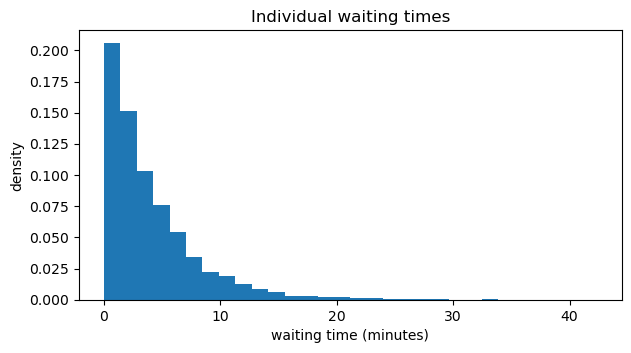

   statistic                                          4 samples  \
0       mean  [4.24189772278076, 4.7654614604193295, 2.44635...   
1  sample SD  [2.7325743189597227, 4.483981536771061, 2.4024...   

                                          40 samples  
0  [4.385406163205318, 5.152007832528879, 4.05688...  
1  [5.8872748799949886, 5.620755036915366, 3.4643...  


In [29]:
rng = np.random.default_rng(1451)
waiting_times = rng.exponential(scale=4.0, size=(5000, 40))

# First, look at the distribution of individual waiting times.
plt.figure(figsize=(7, 3.5))
plt.hist(waiting_times[:, 0], bins=30, density=True)
plt.xlabel("waiting time (minutes)")
plt.ylabel("density")
plt.title("Individual waiting times")
plt.show()

# The row averages are provided so you can focus on the CLT.
means_4 = waiting_times[:, :4].mean(axis=1)
std_4 = waiting_times[:, :4].std(axis=1, ddof = 1)
means_40 = waiting_times.mean(axis=1)
std_40 = waiting_times.std(axis=1, ddof = 1)

# Your summary table, SD comparison, and plots here
summary = pd.DataFrame({
    "statistic": ["mean", "sample SD"],
    "4 samples": [means_4, std_4],
    "40 samples": [means_40, std_40]
})
print(summary)

### B. Interpret (0.5 pt)

Compare center, spread, and shape for the two distributions of averages. Explain what the simulation illustrates about the **central limit theorem**, and distinguish it from the **law of large numbers**.

**Answer:**


## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.


<!-- Paste your session record blocks in this cell, one after another. -->

*(session records go here)*
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA3",
  "export_n": 1,
  "session_date": "2026-09-22",
  "messages": [
    {"i": 1, "who": "student", "text": "is this sufficient for question 1 loop solution?: thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]\nsettings = {\"abrupt_change_nm\": 5}\n\nchanges_loop = []\nabrupt_pairs_loop = []\n\n# Your code here\nlength = len(thickness_nm) -1\nfor i in range(length):\n    change = thickness_nm[i+1] - thickness_nm[i]\n    changes_loop.append(change)\n    if change >= 5:\n        abrupt_pairs_loop.append([i+1,i + 2]) # additional 1 added to account for 0 indexing\n\nprint(changes_loop)\nprint(abrupt_pairs_loop)", "code": true},
    {"i": 2, "who": "tutor", "text": "You're most of the way there — the loop range, the change calculation, and the 1-based pair numbering all look right, and changes_loop is filling correctly. One thing to check against the rule as written: the prompt says abrupt means a change of 5 nm or more in magnitude. Your test is `if change >= 5:` which only catches changes that are large and positive. What happens with your test if a change were, say, -6? Would it get flagged as abrupt under your current condition, and does that match what magnitude means? Take a look at your changes_loop output and see if there's a function you already know that would fix this before you check the size."},
    {"i": 3, "who": "student", "text": "I'm struggling with the end of the vectorized solution. I have the boolean mask, how do I get the pairs?"},
    {"i": 4, "who": "tutor", "text": "Explained np.where(mask)[0] on a toy example to convert a Boolean mask into index positions, then asked the student to work out the position-pair mapping for their own data using the 1-based shift from part A."},
    {"i": 5, "who": "student", "text": "but the position pair is between two values, not a value and an index. how do I do this for different size arrays"},
    {"i": 6, "who": "tutor", "text": "Clarified that pairs store position numbers (not values), same as part A, and showed a generic list-comprehension example (i+1, i+2) over idx on toy data, then asked the student to apply the same mapping to their own idx and check against abrupt_pairs_loop."},
    {"i": 7, "who": "student", "text": "what's going wrong for question 2 part a: #verify with numpy\ncounts, edges = np.histogram(scores, bins, density = True)\nbin_width = edges[1] - edges[0]\nrelative_frequency = counts / scores.size\ndensities = relative_frequency / bin_width\nhistogram_area = (densities * bin_width).sum()\nprint(histogram_area)", "code": true},
    {"i": 8, "who": "tutor", "text": "Pointed out that with density=True, counts already returns density heights, so dividing by scores.size again double-counts; asked the student to print counts and check what it represents."},
    {"i": 9, "who": "student", "text": "I removed that step and replaced relative frequency with counts from the next line but it's still not equal to 1"},
    {"i": 10, "who": "tutor", "text": "Walked through why dividing by bin_width then multiplying by bin_width cancels out, noted density=True guarantees area 1 by definition, and asked the student to check whether bins had been reassigned earlier (e.g. in plotting code) rather than remaining np.arange(25, 76, 5)."},
    {"i": 11, "who": "student", "text": "it still says .2"},
    {"i": 12, "who": "tutor", "text": "Noted 0.2 = 1/5 lines up suspiciously with the bin width, and asked the student to print edges, bin_width, and counts to check whether bins had been reassigned to a scalar or edges no longer matched the expected 10-bin array."},
    {"i": 13, "who": "student", "text": "how would I make summary table for question 4"},
    {"i": 14, "who": "tutor", "text": "Explained pd.DataFrame built from a dictionary with a generic two-group example, reminded the student that np.std defaults to ddof=0 (population) but the prompt asks for sample SD, and asked them to build means_4.mean(), means_4.std(ddof=1), and the same for means_40, then assemble the table."},
    {"i": 15, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 1, "part": "3-1A", "type": "code"},
    {"i": 3, "part": "3-1B", "type": "code"},
    {"i": 7, "part": "3-2A", "type": "code"},
    {"i": 13, "part": "3-4A", "type": "code"}
  ],
  "parts": [
    {"part": "3-1A", "exchanges": 1, "max_tier": 2, "passed": false},
    {"part": "3-1B", "exchanges": 2, "max_tier": 2, "passed": false},
    {"part": "3-2A", "exchanges": 3, "max_tier": 3, "passed": false},
    {"part": "3-4A", "exchanges": 1, "max_tier": 2, "passed": false}
  ],
  "tutor_assessment": [
    "The longest stall was 3-2A (density histogram area check): repeated debugging across three exchanges, tracing a persistent 0.2 result likely caused by a reassigned or misused bins variable, not yet resolved by session end.",
    "No release valve or 'I got it' shortcuts were used this session; all steps were worked through incrementally with genuine attempts, so no concerns about tutoring effectiveness."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.
